<a href="https://colab.research.google.com/github/Lekanggy/MLrepo/blob/main/Classification(.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Effect of Regularization on Deep NN(Using Dropout and Weight-Decay, L2-Regularization)

## Import The tools

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim

## EDA on the dataset

In [2]:
# Load dataset
df = pd.read_csv("yeast.csv")

# Separate features and target
X = df.drop(columns=["localization_site"])
y = df["localization_site"]

# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_
num_classes = len(class_names)

## Spilt data into training and test data

In [3]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded
)

## Standardize the data(Scaling the data at the same standard)

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_temp_scaled = scaler.transform(X_temp)

#Split the temporay data into test and validation
X_test, X_val, y_test, y_val = train_test_split(
    X_temp_scaled, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

## Convert to Pytorch tensor

In [5]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

# Confirm shapes
print(f"✅ Train set: {X_train_tensor.shape}")
print(f"✅ Validation set: {X_val_tensor.shape}")
print(f"✅ Test set: {X_test_tensor.shape}")
print(f"✅ Number of Classes: {num_classes}")
print(f"✅ Class Names: {class_names}")

✅ Train set: torch.Size([1038, 8])
✅ Validation set: torch.Size([223, 8])
✅ Test set: torch.Size([223, 8])
✅ Number of Classes: 10
✅ Class Names: ['CYT' 'ERL' 'EXC' 'ME1' 'ME2' 'ME3' 'MIT' 'NUC' 'POX' 'VAC']


## Inspect Class distribution

In [8]:
counts = torch.unique(y_train_tensor, return_counts=True)[1]

print("Class Distribution")
for index, count in zip(class_names, counts):
    print(f"{index}: {count}")

Class Distribution
CYT: 324
ERL: 3
EXC: 24
ME1: 31
ME2: 36
ME3: 114
MIT: 171
NUC: 300
POX: 14
VAC: 21


The above shows the distribution of the class and that signify the imbalance in the dataset.

#Plot the distribution of the dataset


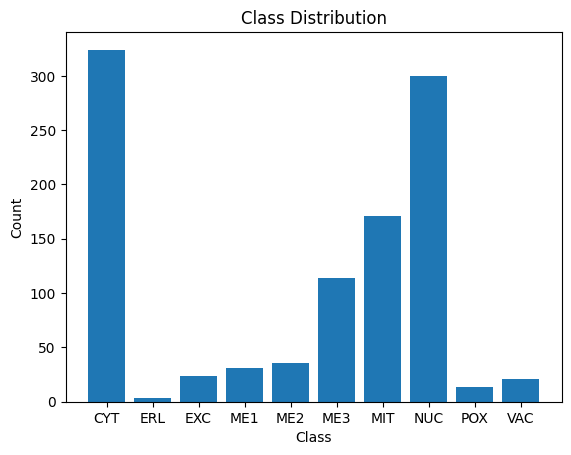

In [11]:
#Plot the distributionof the dataset
plt.bar(class_names, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show();

## Building the Model

### Using Dropout regularization

In [13]:
#Define the parameter
input_size = X_train_tensor.shape[1]
hidden_size = 128
output_dim = len(class_names)

In [14]:
class DropoutModel(nn.Module):
  def __init__(self, input_size, hidden_size, num_classes, drop_prob=0.5):
    super(DropoutModel, self).__init__()
    self.network = nn.Sequential(
        nn.Linear(input_size, hidden_size),
        nn.ReLU(),
        nn.Dropout(p=drop_prob),
        nn.Linear(hidden_size, num_classes)
    )

  def forward(self, x):
    return self.network(x)

model_dropout = DropoutModel(input_size, hidden_size, num_classes, drop_prob=0.5)

print(model_dropout)

DropoutModel(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


## Set up Training Loop for a fullbatch

In [15]:
epochs = 1000
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_dropout.parameters(), lr=0.001)

trainig_losses_drop = []
val_losses_drop = []

for epoch in range(epochs):
  #Training
  model_dropout.train()
  optimizer.zero_grad();
  outputs = model_dropout(X_train_tensor)
  loss = loss_fn(outputs, y_train_tensor)
  loss.backward()
  optimizer.step()
  trainig_losses_drop.append(loss.item())

  #Validation
  model_dropout.eval()
  with torch.no_grad():
    val_outputs = model_dropout(X_val_tensor)
    val_loss = loss_fn(val_outputs, y_val_tensor)
    val_losses_drop.append(val_loss.item())

  if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}: Train Loss = {loss.item():.4f}, Val Loss = {val_loss.item():.4f}")


Epoch 50: Train Loss = 1.4698, Val Loss = 1.4030
Epoch 100: Train Loss = 1.2132, Val Loss = 1.1030
Epoch 150: Train Loss = 1.1020, Val Loss = 1.0078
Epoch 200: Train Loss = 1.0962, Val Loss = 0.9682
Epoch 250: Train Loss = 1.0712, Val Loss = 0.9490
Epoch 300: Train Loss = 1.0286, Val Loss = 0.9377
Epoch 350: Train Loss = 1.0348, Val Loss = 0.9272
Epoch 400: Train Loss = 1.0106, Val Loss = 0.9224
Epoch 450: Train Loss = 1.0021, Val Loss = 0.9174
Epoch 500: Train Loss = 0.9925, Val Loss = 0.9136
Epoch 550: Train Loss = 0.9932, Val Loss = 0.9111
Epoch 600: Train Loss = 0.9773, Val Loss = 0.9088
Epoch 650: Train Loss = 0.9809, Val Loss = 0.9054
Epoch 700: Train Loss = 0.9986, Val Loss = 0.9048
Epoch 750: Train Loss = 0.9699, Val Loss = 0.9045
Epoch 800: Train Loss = 0.9581, Val Loss = 0.9036
Epoch 850: Train Loss = 0.9660, Val Loss = 0.9020
Epoch 900: Train Loss = 0.9600, Val Loss = 0.8982
Epoch 950: Train Loss = 0.9599, Val Loss = 0.8978
Epoch 1000: Train Loss = 0.9619, Val Loss = 0.8958


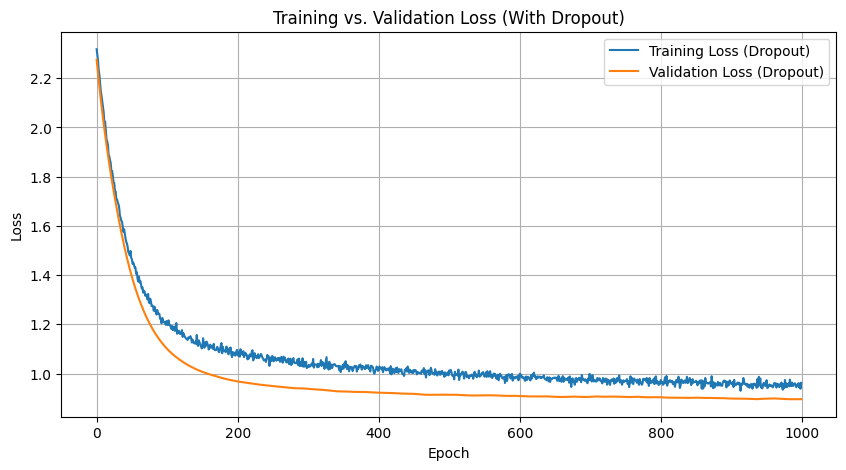

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(trainig_losses_drop, label='Training Loss (Dropout)')
plt.plot(val_losses_drop, label='Validation Loss (Dropout)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss (With Dropout)')
plt.legend()
plt.grid(True)
plt.show()

The graph above shows the training and validation loss over 1000 epochs for the model with dropout regularization.

**The Training Loss (Dropout)** line shows the loss of the model on the training data. It generally decreases over the epochs, indicating that the model is learning to fit the training data.

**The Validation Loss (Dropout)** line shows the loss of the model on the validation data. It also decreases initially and then seems to level off, suggesting that the model is generalizing reasonably well to unseen data, and the dropout is helping to prevent overfitting.
The gap between the training and validation loss suggests some overfitting is still occurring, but it's not drastically increasing, which is a good sign for the effectiveness of dropout.

## Using Weight-Decay(L2-Regulariation)

In [19]:

# Model (same as before)
class L2Model(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(L2Model, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        return self.model(x)

# Instantiate model
model_l2_reg = L2Model(input_size=8, hidden_size=128, output_size=10)

# Loss and optimizer with weight decay (L2 regularization)
loss_fn_reg = nn.CrossEntropyLoss()
optimizer_reg = optim.Adam(model_l2_reg.parameters(), lr=0.001, weight_decay=1e-4)

# Train model
epochs = 1000
training_losses_l2 = []
val_losses_l2 = []

for epoch in range(epochs):
    # Training
    model_l2_reg.train()
    outputs =model_l2_reg(X_train_tensor)
    loss = loss_fn_reg(outputs, y_train_tensor)
    training_losses_l2.append(loss.item())

    # Validation
    model_l2_reg.eval()
    with torch.no_grad():
        val_outputs = model_l2_reg(X_val_tensor)
        val_loss = loss_fn_reg(val_outputs, y_val_tensor)
        val_losses_l2.append(val_loss.item())

    # Backpropagation
    optimizer_reg.zero_grad()
    loss.backward()
    optimizer_reg.step()

    # Optional: Print every 50 epochs
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}: Train Loss = {loss.item():.4f}, Val Loss = {val_loss.item():.4f}")

Epoch 50: Train Loss = 1.3870, Val Loss = 1.3612
Epoch 100: Train Loss = 1.1180, Val Loss = 1.0689
Epoch 150: Train Loss = 1.0389, Val Loss = 0.9827
Epoch 200: Train Loss = 0.9979, Val Loss = 0.9428
Epoch 250: Train Loss = 0.9691, Val Loss = 0.9225
Epoch 300: Train Loss = 0.9463, Val Loss = 0.9108
Epoch 350: Train Loss = 0.9275, Val Loss = 0.9045
Epoch 400: Train Loss = 0.9111, Val Loss = 0.9025
Epoch 450: Train Loss = 0.8963, Val Loss = 0.9012
Epoch 500: Train Loss = 0.8819, Val Loss = 0.9028
Epoch 550: Train Loss = 0.8678, Val Loss = 0.9042
Epoch 600: Train Loss = 0.8541, Val Loss = 0.9063
Epoch 650: Train Loss = 0.8404, Val Loss = 0.9106
Epoch 700: Train Loss = 0.8265, Val Loss = 0.9156
Epoch 750: Train Loss = 0.8121, Val Loss = 0.9221
Epoch 800: Train Loss = 0.7979, Val Loss = 0.9294
Epoch 850: Train Loss = 0.7838, Val Loss = 0.9376
Epoch 900: Train Loss = 0.7694, Val Loss = 0.9458
Epoch 950: Train Loss = 0.7541, Val Loss = 0.9536
Epoch 1000: Train Loss = 0.7387, Val Loss = 0.9606


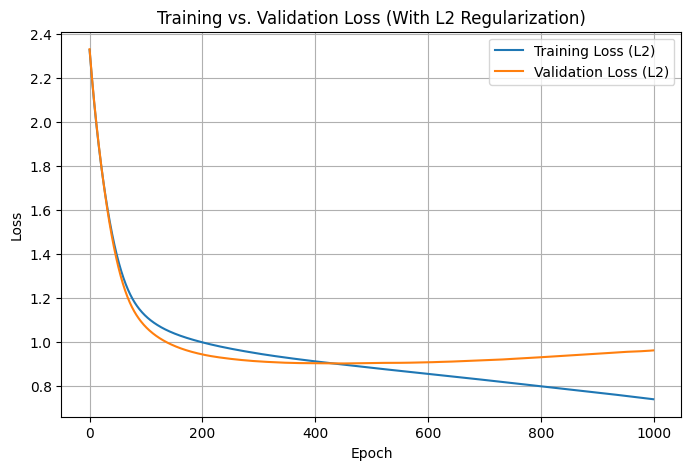

In [20]:
# Plot training vs. validation loss

plt.figure(figsize=(8, 5))
plt.plot(training_losses_l2, label="Training Loss (L2)")
plt.plot(val_losses_l2, label="Validation Loss (L2)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs. Validation Loss (With L2 Regularization)")
plt.legend()
plt.grid(True)
plt.show()

The graph above displays the training and validation loss curves for the model trained with L2 regularization (weight decay) over 1000 epochs.

**The Training Loss (L2)** line shows the loss on the training dataset. You can observe a continuous decrease in this loss throughout the epochs, which indicates that the model is effectively learning from the training data.

**The Validation Loss (L2)** line shows the loss on the validation dataset. Initially, this loss decreases, but after a certain point (around epoch 400-500), it starts to increase. This divergence between the training and validation loss suggests that the model is starting to overfit the training data, and the L2 regularization with the current weight_decay value might not be strong enough to prevent this overfitting effectively

### Combining the Two regularizations


In [30]:
#Define the Base model
class Dropout_L2_Model(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout_prob=0.5):
        super(Dropout_L2_Model, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        return self.network(x)



dropout_l2 = Dropout_L2_Model(input_size=8, hidden_size=128, output_size=10, dropout_prob=0.5)
print(dropout_l2)

Dropout_L2_Model(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [31]:
#Define the trainig parameters and the traning loops

loss_fn_dl = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(dropout_l2.parameters(), lr=0.001, weight_decay=1e-4)

train_losses_dropout_L2 = []
val_losses_dropout_L2 = []

for epoch in range(1000):
    dropout_l2.train()
    y_pred = dropout_l2(X_train_tensor)
    loss = loss_fn_dl(y_pred, y_train_tensor)
    train_losses_dropout_L2.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Validation
    dropout_l2.eval()
    with torch.no_grad():
        val_output = dropout_l2(X_val_tensor)
        val_loss = loss_fn_dl(val_output, y_val_tensor)
        val_losses_dropout_L2.append(val_loss.item())
        # Optional: Print every 50 epochs
    if (epoch+1) % 50 == 0:
      print(f"Epoch {epoch+1}: Train Loss = {loss.item():.4f}, Val Loss = {val_loss.item():.4f}")

Epoch 50: Train Loss = 1.4696, Val Loss = 1.3876
Epoch 100: Train Loss = 1.2246, Val Loss = 1.0984
Epoch 150: Train Loss = 1.1180, Val Loss = 1.0086
Epoch 200: Train Loss = 1.0816, Val Loss = 0.9677
Epoch 250: Train Loss = 1.0517, Val Loss = 0.9473
Epoch 300: Train Loss = 1.0537, Val Loss = 0.9341
Epoch 350: Train Loss = 1.0234, Val Loss = 0.9246
Epoch 400: Train Loss = 1.0162, Val Loss = 0.9211
Epoch 450: Train Loss = 1.0117, Val Loss = 0.9138
Epoch 500: Train Loss = 0.9749, Val Loss = 0.9110
Epoch 550: Train Loss = 1.0121, Val Loss = 0.9086
Epoch 600: Train Loss = 0.9736, Val Loss = 0.9099
Epoch 650: Train Loss = 0.9883, Val Loss = 0.9090
Epoch 700: Train Loss = 0.9739, Val Loss = 0.9065
Epoch 750: Train Loss = 0.9713, Val Loss = 0.9044
Epoch 800: Train Loss = 0.9949, Val Loss = 0.9063
Epoch 850: Train Loss = 0.9491, Val Loss = 0.9029
Epoch 900: Train Loss = 0.9612, Val Loss = 0.9021
Epoch 950: Train Loss = 0.9534, Val Loss = 0.9025
Epoch 1000: Train Loss = 0.9468, Val Loss = 0.9011


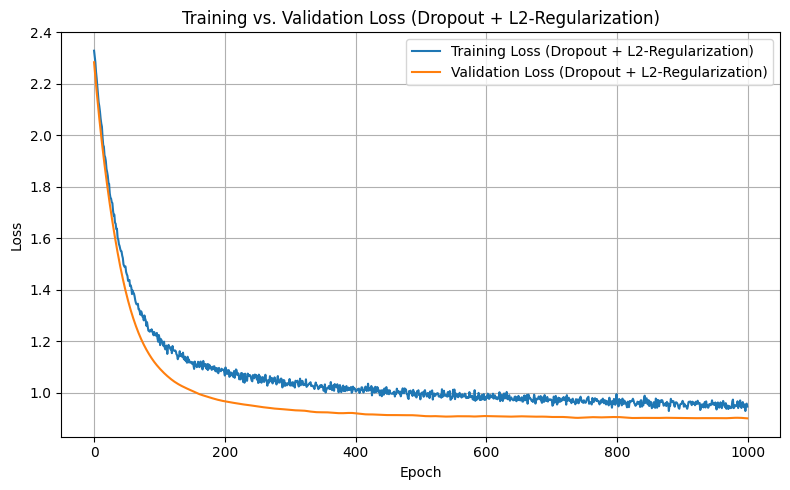

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_dropout_L2, label="Training Loss (Dropout + L2-Regularization)")
plt.plot(val_losses_dropout_L2, label="Validation Loss (Dropout + L2-Regularization)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs. Validation Loss (Dropout + L2-Regularization)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The graph displays the training and validation loss curves for the model using both Dropout and L2 regularization.

**The Training Loss (Dropout + L2-Regularization)** line shows the loss on the training dataset. It generally decreases over the epochs.

**The Validation Loss (Dropout + L2-Regularization)** line shows the loss on the validation dataset. It decreases initially and then seems to level off, similar to the model with only Dropout.

Compared to the L2 regularization only model, the combined regularization approach appears to be more effective at preventing the validation loss from increasing, suggesting better generalization and less overfitting.

#Summary Plots of the Three Models

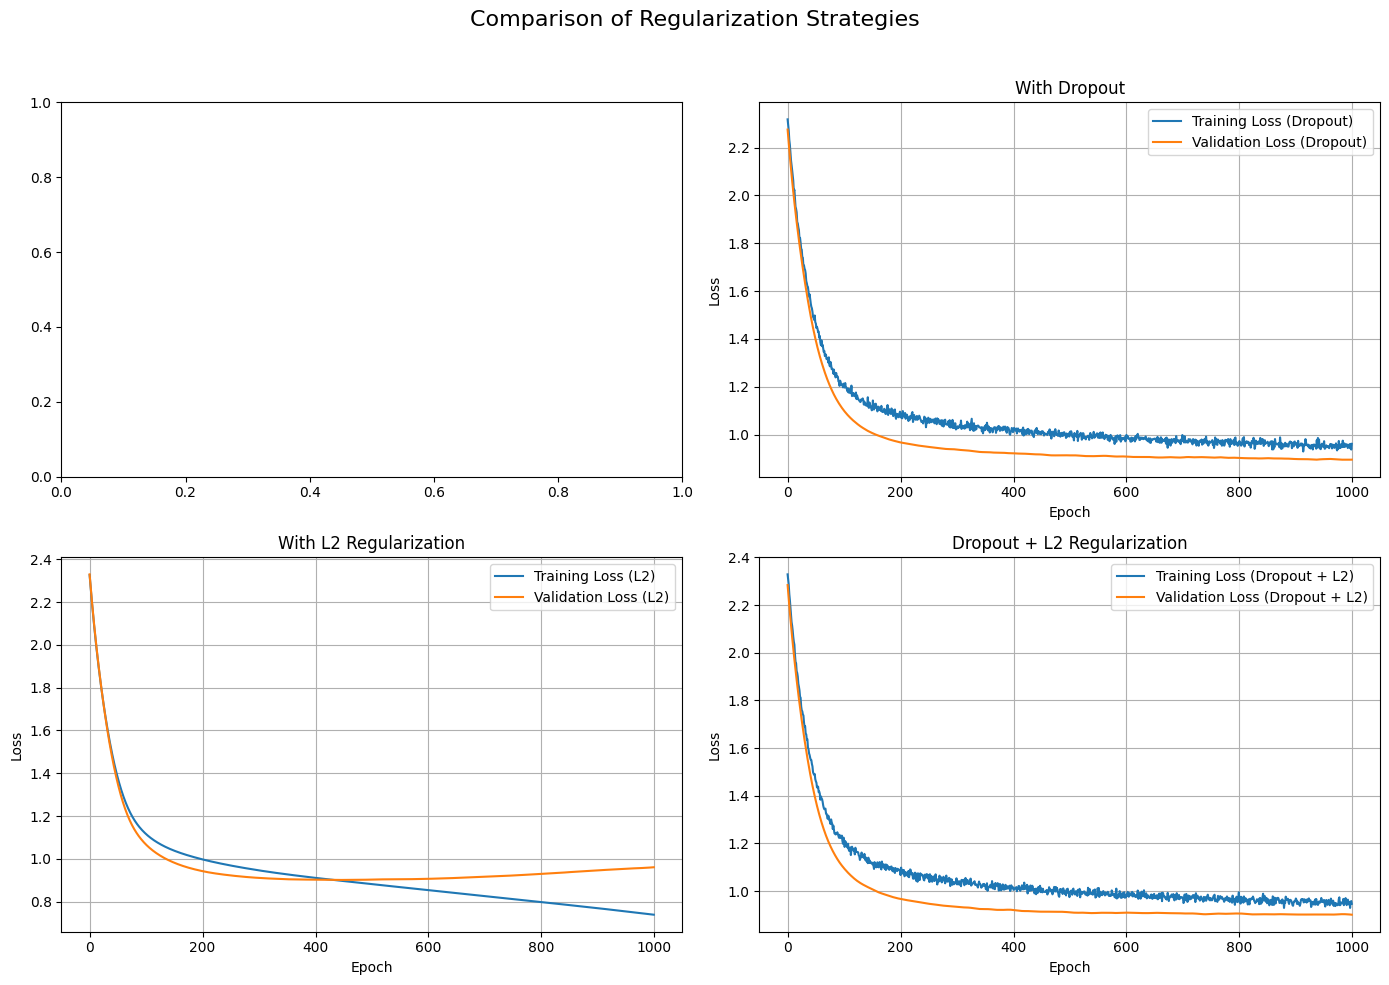

In [33]:


# Create 2x2 subplot grid
fig, axs = plt.subplots(2, 2, figsize=(14, 10))


# Plot 2: Dropout
axs[0, 1].plot(trainig_losses_drop, label="Training Loss (Dropout)")
axs[0, 1].plot(val_losses_drop, label="Validation Loss (Dropout)")
axs[0, 1].set_title("With Dropout")
axs[0, 1].set_xlabel("Epoch")
axs[0, 1].set_ylabel("Loss")
axs[0, 1].legend()
axs[0, 1].grid(True)

# Plot 3: L2 Regularization
axs[1, 0].plot(training_losses_l2, label="Training Loss (L2)")
axs[1, 0].plot(val_losses_l2, label="Validation Loss (L2)")
axs[1, 0].set_title("With L2 Regularization")
axs[1, 0].set_xlabel("Epoch")
axs[1, 0].set_ylabel("Loss")
axs[1, 0].legend()
axs[1, 0].grid(True)

# Plot 4: Dropout + L2
axs[1, 1].plot(train_losses_dropout_L2, label="Training Loss (Dropout + L2)")
axs[1, 1].plot(val_losses_dropout_L2, label="Validation Loss (Dropout + L2)")
axs[1, 1].set_title("Dropout + L2 Regularization")
axs[1, 1].set_xlabel("Epoch")
axs[1, 1].set_ylabel("Loss")
axs[1, 1].legend()
axs[1, 1].grid(True)

# Final layout adjustments
plt.suptitle("Comparison of Regularization Strategies", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


#Evaluation of the Three Models

In [34]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

def evaluate_model(model, X_test_tensor, y_test_tensor):
    model.eval()
    with torch.no_grad():
        logits = model(X_test_tensor)
        preds = torch.argmax(logits, dim=1)

    y_true = y_test_tensor.cpu().numpy()
    y_pred = preds.cpu().numpy()

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    return acc, f1



# Evaluate Dropout Only (M2)
acc_m2, f1_m2 = evaluate_model(model_dropout, X_test_tensor, y_test_tensor)

# Evaluate L2 Regularization Only (M3)
acc_m3, f1_m3 = evaluate_model(model_l2_reg, X_test_tensor, y_test_tensor)

# Evaluate Dropout + L2 (M4)
acc_m4, f1_m4 = evaluate_model(dropout_l2, X_test_tensor, y_test_tensor)

results = {
    "Model": ["Dropout (M2)", "L2 (M3)", "Dropout + L2 (M4)"],
    "Test Accuracy": [acc_m2, acc_m3, acc_m4],
    "Macro F1 Score": [f1_m2, f1_m3, f1_m4]
}

results_df = pd.DataFrame(results)
print(results_df)

               Model  Test Accuracy  Macro F1 Score
0       Dropout (M2)       0.600897        0.560867
1            L2 (M3)       0.573991        0.566597
2  Dropout + L2 (M4)       0.582960        0.602095


From these results, the model with both Dropout and L2 regularization achieved the highest Macro F1 Score, which is a good indicator for imbalanced datasets. The Dropout-only model had the highest Test Accuracy, but the Macro F1 score is often a better metric for evaluating performance across all classes in an imbalanced dataset like this one.